# Application 5 — Instant-SIM: RNA polymerase II clusters in zebrafish embryos

**Modality:** instant structured illumination microscopy (iSIM), live imaging.
**Objects:** nuclei and RNA polymerase II (Pol II Ser5P) clusters in a sphere-stage zebrafish embryo.

**Data:** Hajiabadi, H., Mamontova, I., Prizak, R., Pancholi, A., Koziolek, A. and Hilbert, L. (2022).
*Deep-learning microscopy image reconstruction with quality control reveals second-scale rearrangements in RNA polymerase II clusters.*
PNAS Nexus 1(3):pgac065, [doi:10.1093/pnasnexus/pgac065](https://doi.org/10.1093/pnasnexus/pgac065).
Stack from the paper's data record: Hajiabadi, H. (2021), Zenodo,
[doi:10.5281/zenodo.5568871](https://doi.org/10.5281/zenodo.5568871), licence CC-BY-4.0
(`Processed_images.zip`, member `Processed_images/EmbryoA/highSNR_100ms1.tif`: one 3D stack, Pol II Ser5P channel, 100 ms exposure).

**What this notebook does:** reads the one stack (12 MB of the 1.37 GB archive) with HTTP range requests,
proposes boxes for nuclei and Pol II clusters with a threshold segmentation adapted from the paper's analysis
(the data carry no annotations), loads the boxes into the synchronized four-viewer layout,
replays a mouse drag, and exports the boxes, including a two-class COCO file (nucleus, cluster).
Boxes from a threshold segmentation are **proposals**: this is exactly the situation in which they are reviewed and corrected in napari.

In [1]:
SHOW = False  # True: open the four napari windows (needs a desktop session)

if SHOW:
    get_ipython().run_line_magic("gui", "qt")

import json
from pathlib import Path

import numpy as np
from IPython.display import Image, display

import tutorial_utils as tu

CASE = "05_instant_sim_polii_clusters"
DATA = tu.data_dir('hajiabadi_isim')  # $TURBOBOX_DATA/<subdir>, else ~/.cache/napari-turbobox/<subdir>
OUT = DATA / "export"
print("data directory:", tu.show_path(DATA))

data directory: ~/.cache/napari-turbobox/hajiabadi_isim


## 1. Download


The archive is 1.37 GB; only its directory and the one member are transferred (`tu.fetch_zip_member`).
`zipfile` checks the member's CRC-32 from the archive; the extracted file is also compared with its sha256.
Zenodo publishes an MD5 only for the whole archive (`4b32c8ae9028e679ef973b28ac55f164`), so the member's sha256 below was computed by us.

In [2]:
ZIP_URL = "https://zenodo.org/records/5568871/files/Processed_images.zip"
MEMBER = "Processed_images/EmbryoA/highSNR_100ms1.tif"
stack_path = tu.fetch_zip_member(
    ZIP_URL, MEMBER, DATA / "EmbryoA_highSNR_100ms1.tif",
    sha256="c6adc04a308e4698444f6e6d10b014b12363b9bbd8e490a4056d319b02953343",
)

## 2. Load the volume


The stack is `(z, y, x) = (21, 599, 799)`, `float32` (camera counts divided by 65,535). The TIFF carries no voxel size;
we use 0.2 µm × 0.0659 µm × 0.0659 µm from the microscope metadata of the same experiment (100x silicone objective, 0.2 µm z-step),
as stored in the raw files of the companion record (Zenodo 5566880).

In [3]:
import tifffile

image = tifffile.imread(stack_path)
VOXEL = np.array([0.2, 0.0659, 0.0659])  # µm (z, y, x)
SCALE = tuple(VOXEL)
CONTRAST = None
print("stack", image.shape, image.dtype, f"range {image.min():.4f}-{image.max():.4f}")

stack (21, 599, 799) float32 range 0.0008-0.0102


## 3. One box per object


Segmentation adapted from the analysis in Hajiabadi et al. (2022; supplementary methods):

- **Nuclei:** Gaussian blur (σ = 1 µm) minus a background blur (σ = 10 µm), Otsu threshold, components larger than 40 µm³.
- **Pol II clusters:** inside the nuclei, the image minus a background blur (σ = 3 µm), threshold at mean + 2 SD (computed inside the nuclei),
  3D components (26-connectivity) of at least 0.03 µm³.

Each component becomes one box (category 0 = nucleus, 1 = Pol II cluster). The nuclei are cut by the edges of the imaged field and
span the whole stack in z, so their boxes do too.

In [4]:
from scipy import ndimage as ndi
from skimage.filters import threshold_otsu

img = image.astype(np.float32)
dog = ndi.gaussian_filter(img, 1.0 / VOXEL) - ndi.gaussian_filter(img, 10.0 / VOXEL)
nuc_lab, _ = ndi.label(dog > threshold_otsu(dog))
nuc_vol = np.bincount(nuc_lab.ravel()) * VOXEL.prod()
nuclei = np.isin(nuc_lab, [i for i in np.flatnonzero(nuc_vol > 40) if i > 0])

residual = img - ndi.gaussian_filter(img, 3.0 / VOXEL)
inside = residual[nuclei]
cl_lab, _ = ndi.label((residual > inside.mean() + 2 * inside.std()) & nuclei, structure=np.ones((3, 3, 3)))
min_voxels = int(np.ceil(0.03 / VOXEL.prod()))
cl_size = np.bincount(cl_lab.ravel())
clusters = np.where(np.isin(cl_lab, [i for i in np.flatnonzero(cl_size >= min_voxels) if i > 0]), cl_lab, 0)

nuc_boxes, _ = tu.labels_to_boxes(ndi.label(nuclei)[0])
cl_boxes, _ = tu.labels_to_boxes(clusters)
boxes = np.concatenate([nuc_boxes, cl_boxes])
cats = [0] * len(nuc_boxes) + [1] * len(cl_boxes)
ids = np.arange(1, len(boxes) + 1)
print(len(nuc_boxes), "nuclei,", len(cl_boxes), f"clusters (>= {min_voxels} voxels = 0.03 µm³)")
print("median cluster box extent (z, y, x) in voxels:", np.median(cl_boxes[:, 1] - cl_boxes[:, 0], axis=0).tolist())

4 nuclei, 34 clusters (>= 35 voxels = 0.03 µm³)
median cluster box extent (z, y, x) in voxels: [6.0, 10.5, 11.5]


In [5]:
check = tu.check_boxes(boxes, image.shape)
print(f"{check['valid']} of {check['boxes']} boxes satisfy 0 <= min, max <= shape - 1, max - min >= 1")
extent = boxes[:, 1] - boxes[:, 0]
print("median box extent (z, y, x) in voxels:", np.median(extent, axis=0).tolist())

38 of 38 boxes satisfy 0 <= min, max <= shape - 1, max - min >= 1
median box extent (z, y, x) in voxels: [6.0, 11.5, 12.0]


## 4. The synchronized four-viewer layout

XY is the editable view; XZ, YZ and 3D are read-only and display the same box store.
`add_boxes` validates every box against the image shape, so a `ValueError` here would mean an invalid box.
The screenshot shows the four canvases (XY, XZ, YZ, 3D), each 2D view on a slice through one median-sized box.

38 boxes in the shared store; shapes drawn per view: [13, 3, 6, 38]


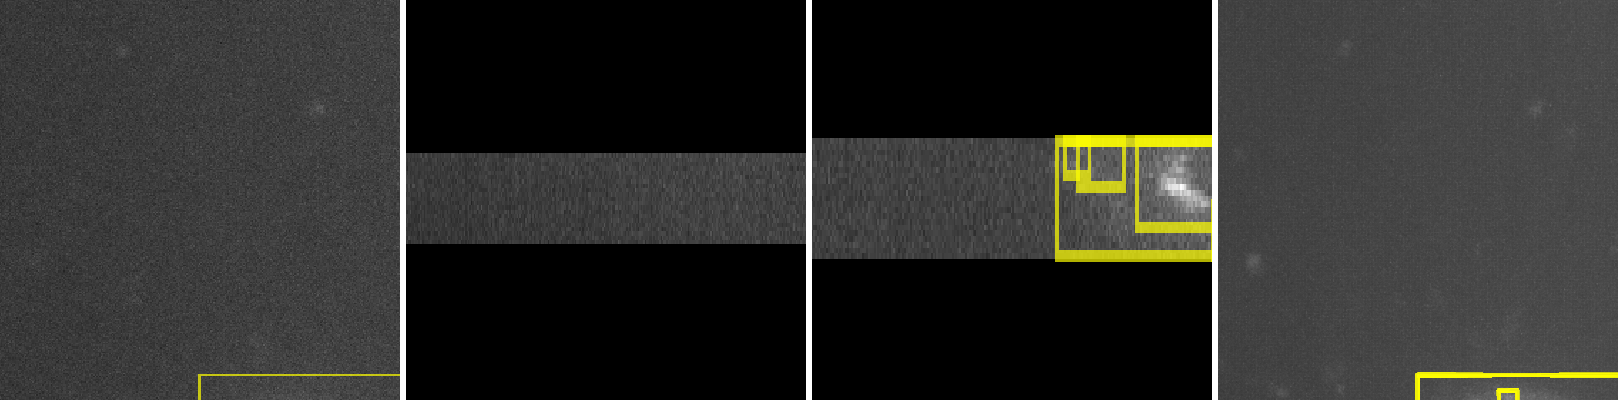

In [6]:
k = tu.pick_box(boxes)
viewers, layers = tu.four_viewer_layout(
    image, boxes, show=SHOW, scale=SCALE, contrast_limits=CONTRAST, focus_box=k
)
print(len(layers[0].bounding_boxes), "boxes in the shared store;",
      "shapes drawn per view:", [lyr.nshapes for lyr in layers])
shot = tu.RESULTS / f"{CASE}_views.png"
tu.screenshot(viewers, shot)
display(Image(filename=str(shot)))

## 5. Replaying a mouse drag

The drag below goes through napari's own mouse-event dispatch, the same path as a real mouse:
it grabs box `k` in the XY view at its centre and moves it by a quarter of its size in y and x.
We check that the box stays a valid box, that the read-only XZ and YZ views and the 3D view show it at the new position,
and that one undo step restores it.

In [7]:
drag = tu.replay_drag(viewers, layers, k)
print("shift (z, y, x):", drag["shift_zyx"], "intended:", drag["intended_shift_zyx"])
print("still a valid box:", drag["valid"])
print("read-only views show the moved box:", drag["views_show_moved_box"])
layers[0].undo()
print("undo restores all boxes:", np.array_equal(layers[0].bounding_boxes, boxes.astype(np.float32)))

shift (z, y, x): [0.0, 42.0, 0.0] intended: [0.0, 42.0, 27.0]
still a valid box: True
read-only views show the moved box: {'XZ (read-only)': True, 'YZ (read-only)': True, '3D (read-only)': True}
undo restores all boxes: True


## 6. Export

Native `boxes.npy` (the format of the control panel's import/export), COCO JSON with one 2D box per slice that a 3D box covers,
and one YOLO label file per slice. Slice images are named `slice_NNNN.png`; the exporter writes no image files.

In [8]:
from napari_turbobox.export import boxes_to_coco

final = layers[0].bounding_boxes
counts = tu.export(final, image.shape, OUT, label_ids=ids)  # boxes.npy, class-agnostic COCO and YOLO
coco2 = boxes_to_coco(final, image.shape, category_ids=cats, category_names={0: "nucleus", 1: "Pol II Ser5P cluster"})
(OUT / "coco_two_classes.json").write_text(json.dumps(coco2))
counts["coco_two_classes_annotations"] = len(coco2["annotations"])
print(json.dumps(counts, indent=1))
print("categories:", coco2["categories"])

{
 "boxes": 38,
 "coco_images": 21,
 "coco_annotations": 342,
 "yolo_files": 21,
 "coco_two_classes_annotations": 342
}
categories: [{'id': 1, 'name': 'nucleus'}, {'id': 2, 'name': 'Pol II Ser5P cluster'}]


In [9]:
result = dict(
    case=CASE,
    modality="instant structured illumination microscopy (iSIM), live",
    objects=f"{len(nuc_boxes)} nuclei + {len(cl_boxes)} RNA Pol II Ser5P clusters (threshold proposals)",
    dataset="Hajiabadi et al. 2022 (PNAS Nexus); Zenodo doi:10.5281/zenodo.5568871 (CC-BY-4.0)",
    volume=MEMBER,
    box_source="threshold segmentation adapted from the paper (no annotations available)",
    n_nuclei=int(len(nuc_boxes)),
    n_clusters=int(len(cl_boxes)),
)
result.update(check=check, export=counts, drag=drag, image_shape=list(image.shape), n_boxes=int(len(boxes)))
print(json.dumps({k: v for k, v in result.items() if k != "drag"}, indent=1))
tu.show_path(tu.save_result(CASE, result))

{
 "case": "05_instant_sim_polii_clusters",
 "modality": "instant structured illumination microscopy (iSIM), live",
 "objects": "4 nuclei + 34 RNA Pol II Ser5P clusters (threshold proposals)",
 "dataset": "Hajiabadi et al. 2022 (PNAS Nexus); Zenodo doi:10.5281/zenodo.5568871 (CC-BY-4.0)",
 "volume": "Processed_images/EmbryoA/highSNR_100ms1.tif",
 "box_source": "threshold segmentation adapted from the paper (no annotations available)",
 "n_nuclei": 4,
 "n_clusters": 34,
 "check": {
  "boxes": 38,
  "valid": 38
 },
 "export": {
  "boxes": 38,
  "coco_images": 21,
  "coco_annotations": 342,
  "yolo_files": 21,
  "coco_two_classes_annotations": 342
 },
 "image_shape": [
  21,
  599,
  799
 ],
 "n_boxes": 38
}


'tutorials/results/05_instant_sim_polii_clusters.json'

In [10]:
if not SHOW:
    for v in viewers:
        v.close()